### Imports

In [85]:
# Adjust import path
import sys
sys.path.append("../PDEs")
sys.path.append("../")

In [86]:
import os
import h5py
import numpy as np

import opinf

import config_fhnlifted as config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4

import matplotlib.pyplot as plt

from jax_gp import *

### Generate Data

In [87]:
training_span = (0, 2) # (0, 6)
num_samples= 100 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [88]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 100 uniformly sampled snapshots over 0.00 ≤ t < 2.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.31 s.


In [89]:
print(f"Models :{model}, time domain: {time_domain.shape}, true states: {true_states.shape}, time domain sampled: {time_domain_sampled.shape}, snapshots sampled: {snapshots_sampled.shape}")

Models :<config_fhnlifted.FullOrderModel object at 0x150427240>, time domain: (801,), true states: (1024, 801), time domain sampled: (100,), snapshots sampled: (1024, 100)


### Fit Guassian Processes

In [90]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 100)
(512, 100) (512, 100)
(3, 801)
done in 0.01 s.


(100, 1) (1, 100)
Iter   0, neg-log-lik = 89666.9688
Iter  10, neg-log-lik = 77692.2188
Iter  20, neg-log-lik = 68657.0625
Iter  30, neg-log-lik = 61141.3945
Iter  40, neg-log-lik = 54145.1562
Iter  50, neg-log-lik = 46311.8008
Iter  60, neg-log-lik = 35808.9375
Iter  70, neg-log-lik = 24822.3555
Iter  80, neg-log-lik = 17373.7969
Iter  90, neg-log-lik = 13841.5352
Iter 100, neg-log-lik = 12335.2441
Iter 110, neg-log-lik = 11500.8457
Iter 120, neg-log-lik = 10882.4180
Iter 130, neg-log-lik = 10332.6436
Iter 140, neg-log-lik = 9789.6084
Iter 150, neg-log-lik = 9214.8018
Iter 160, neg-log-lik = 8580.2148
Iter 170, neg-log-lik = 7873.7031
Iter 180, neg-log-lik = 7119.9722
Iter 190, neg-log-lik = 6392.1719
Iter 200, neg-log-lik = 5771.2119
Iter 210, neg-log-lik = 5284.9102
Iter 220, neg-log-lik = 4906.0889
Iter 230, neg-log-lik = 4591.5103
Iter 240, neg-log-lik = 4305.7090
Iter 250, neg-log-lik = 4024.7996
Iter 260, neg-log-lik = 3735.1462
Iter 270, neg-log-lik = 3434.0830
Iter 280, neg-lo

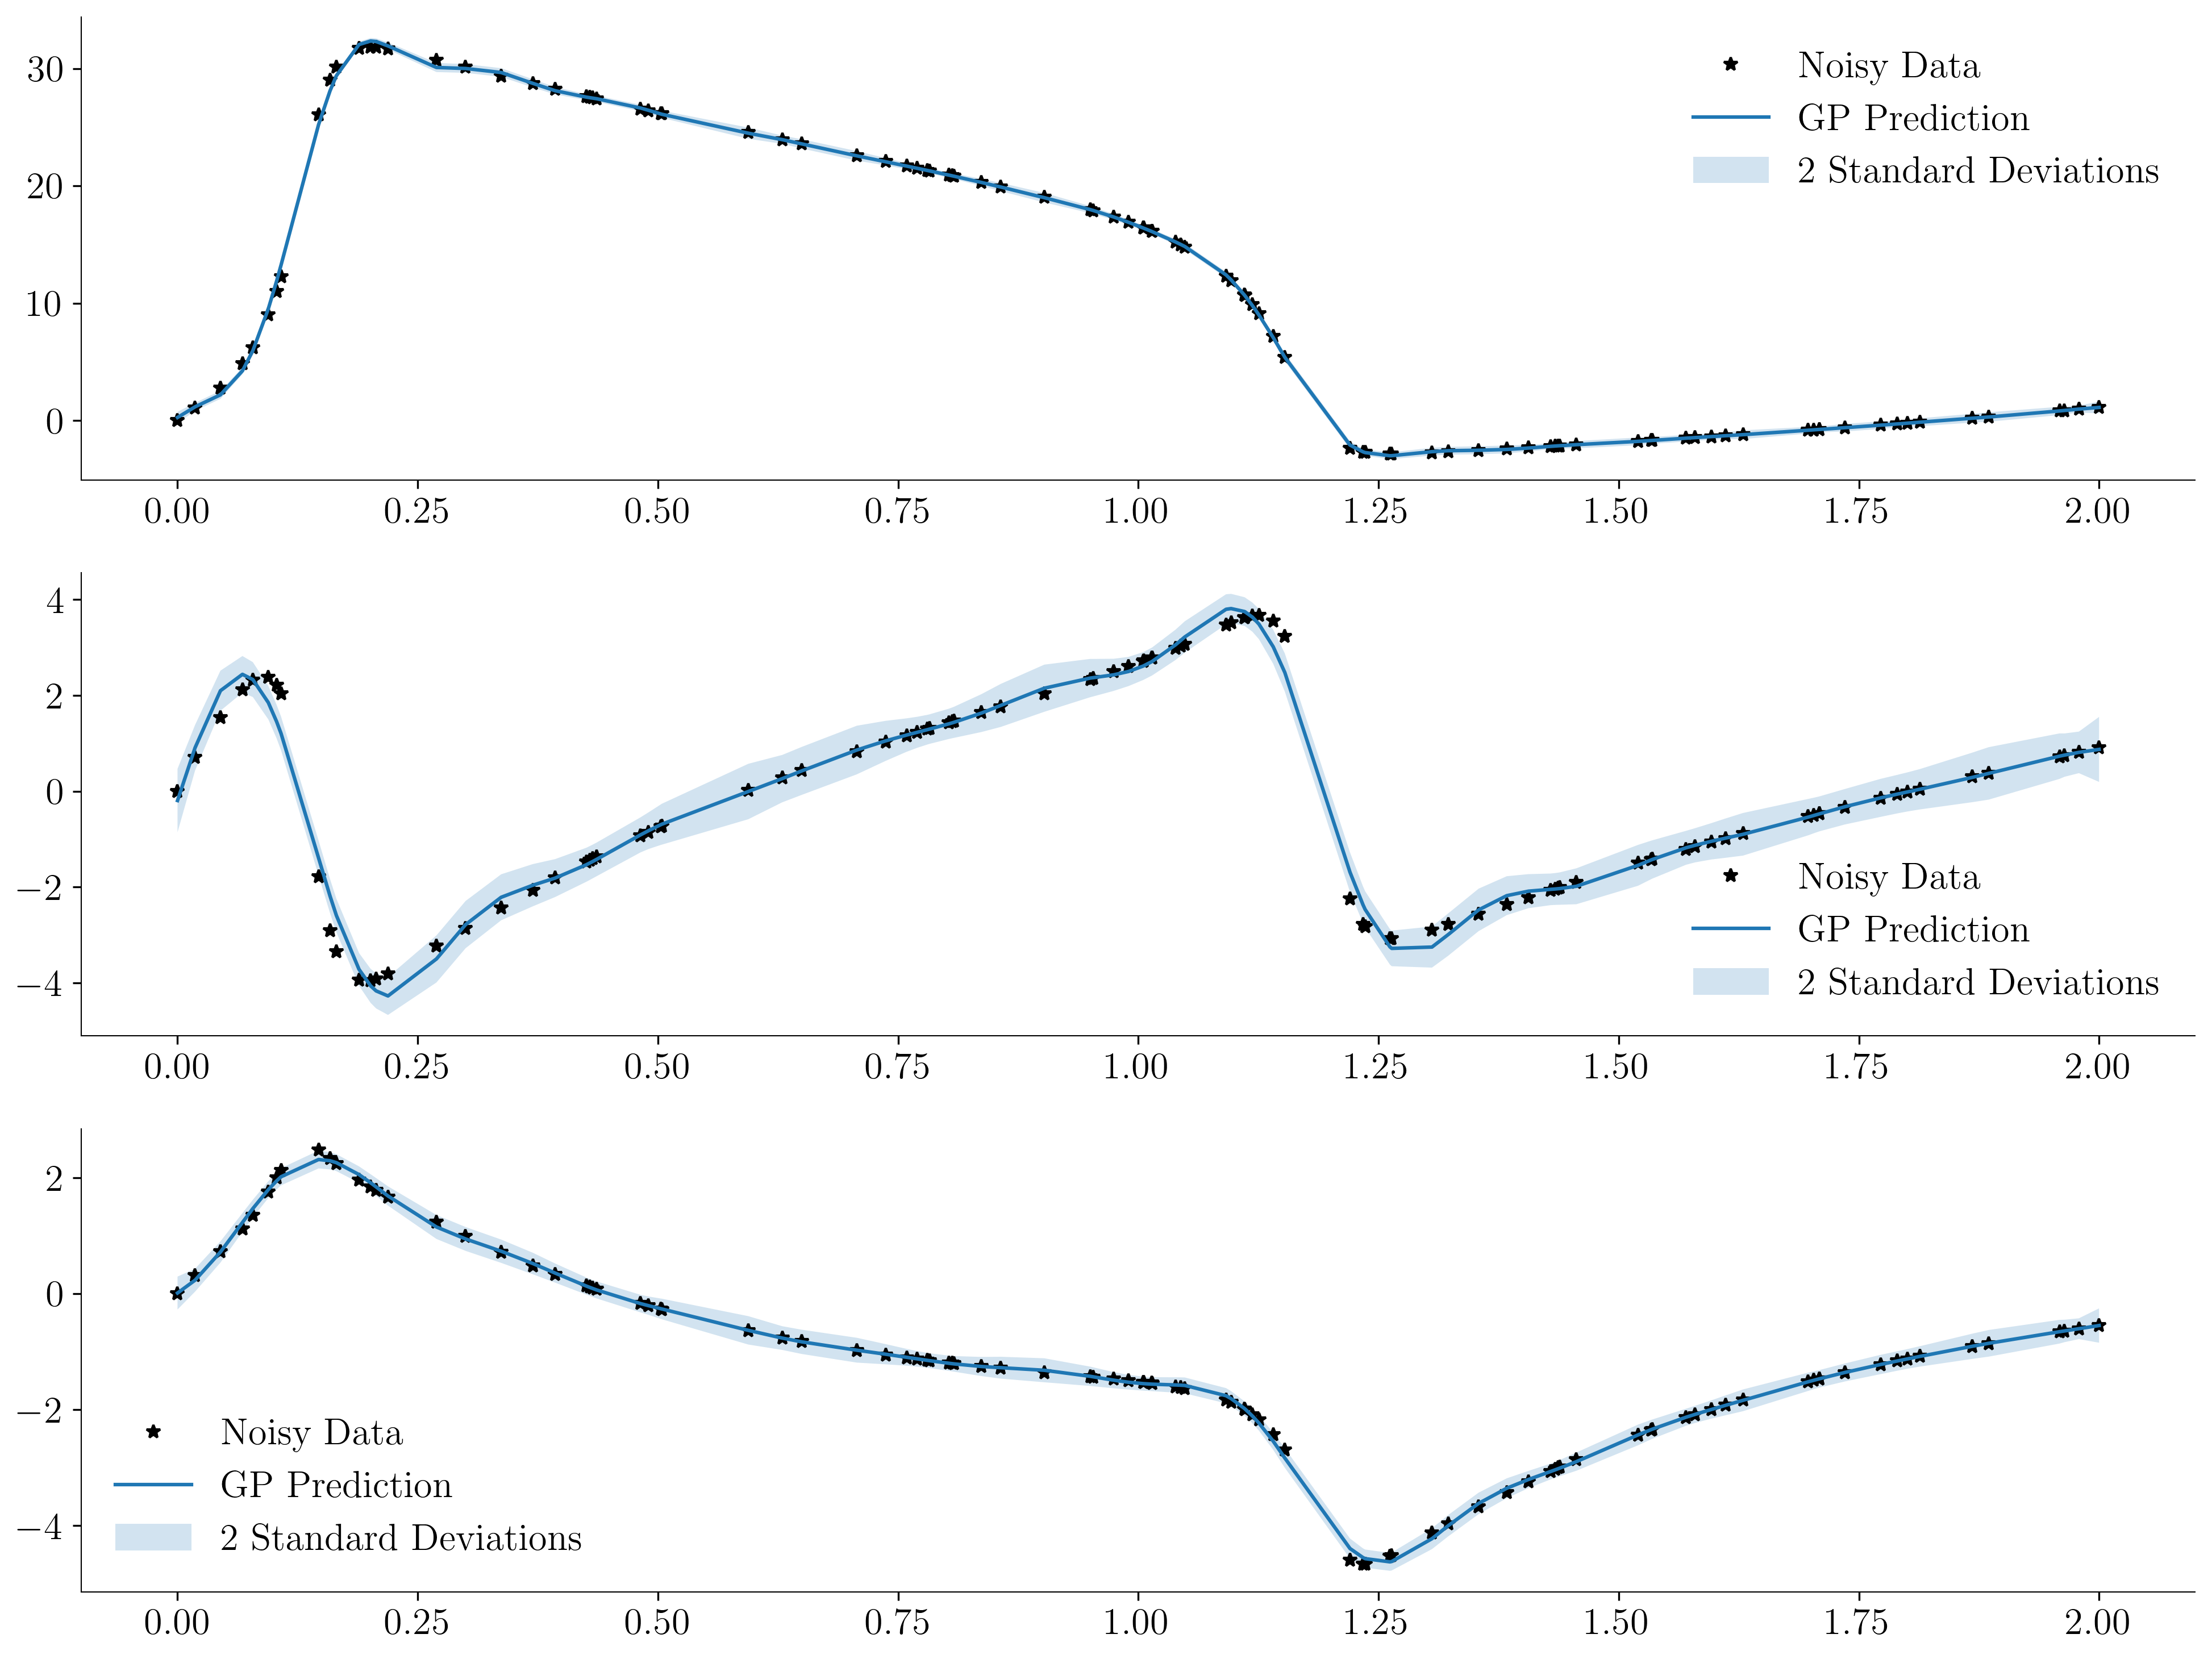

In [91]:
gps = []
fig, ax = plt.subplots(numPODmodes, 1, figsize=(16,12))
for mode in range(numPODmodes):
    gp = GaussianProcess(standardize=False)
    # gp = GaussianProcess(init_params={'variance': 2.1959e+00, 'lengthscale': 4.6282e-02, 'noise': 8.6918e-04})
    print(time_domain_sampled[:,None].shape, snapshots_compressed[mode, :].reshape(1, time_domain_sampled.size).shape)
    gp.fit(X = time_domain_sampled[:,None], y = snapshots_compressed[mode, :].reshape(1, time_domain_sampled.size), n_iter=1000)
    gps.append(gp)

    pred_mu, pred_cov = gp.predict(X_train=time_domain_sampled[:,None], 
                      y_train=snapshots_compressed[mode, :].reshape(time_domain_sampled.size),
                      X_test=time_domain_sampled)

    ax[mode].plot(time_domain_sampled, snapshots_compressed[mode], 'k*', label='Noisy Data')
    ax[mode].plot(time_domain_sampled, pred_mu, label='GP Prediction')
    ax[mode].fill_between(time_domain_sampled, pred_mu - 3*pred_cov, pred_mu + 3*pred_cov, label='2 Standard Deviations', alpha = .2)
    ax[mode].legend() 

#### Compute derivatives of Guassian Processes

In [92]:
K_yys = jnp.stack([gp.get_kernel_matrix(time_domain_sampled, nugget=1e-4) for gp in gps])
K_zys = jnp.stack([gp.get_kernel_derivative_dt1(time_domain_sampled) for gp in gps])
K_zzs = jnp.stack([gp.get_kernel_double_derivative(time_domain_sampled) for gp in gps])
noise_vars = jnp.array([gp.hyperparameters["noise"] for gp in gps])[:, None]*jnp.ones(time_domain_sampled.size)

# then compute Dashs by stacking a list, and call get_dash_c_phi correctly:
Dashs = jnp.stack([
    # gp.get_kernel_derivative_dt1(time) already does get_dash_c_phi(self.params, time)
    gp.get_kernel_derivative_dt1(time_domain_sampled) @ jnp.linalg.solve(K_yys[idx], jnp.eye(time_domain_sampled.shape[0]))
    for idx, gp in enumerate(gps)
])

As    = jnp.array([gp.get_As(time_domain_sampled)[0] for gp in gps])
print(K_yys.shape, K_zys.shape, K_zzs.shape, noise_vars.shape, Dashs.shape, As.shape)

(3, 100, 100) (3, 100, 100) (3, 100, 100) (3, 100) (3, 100, 100) (3, 100, 100)


### The Probabilitic Model

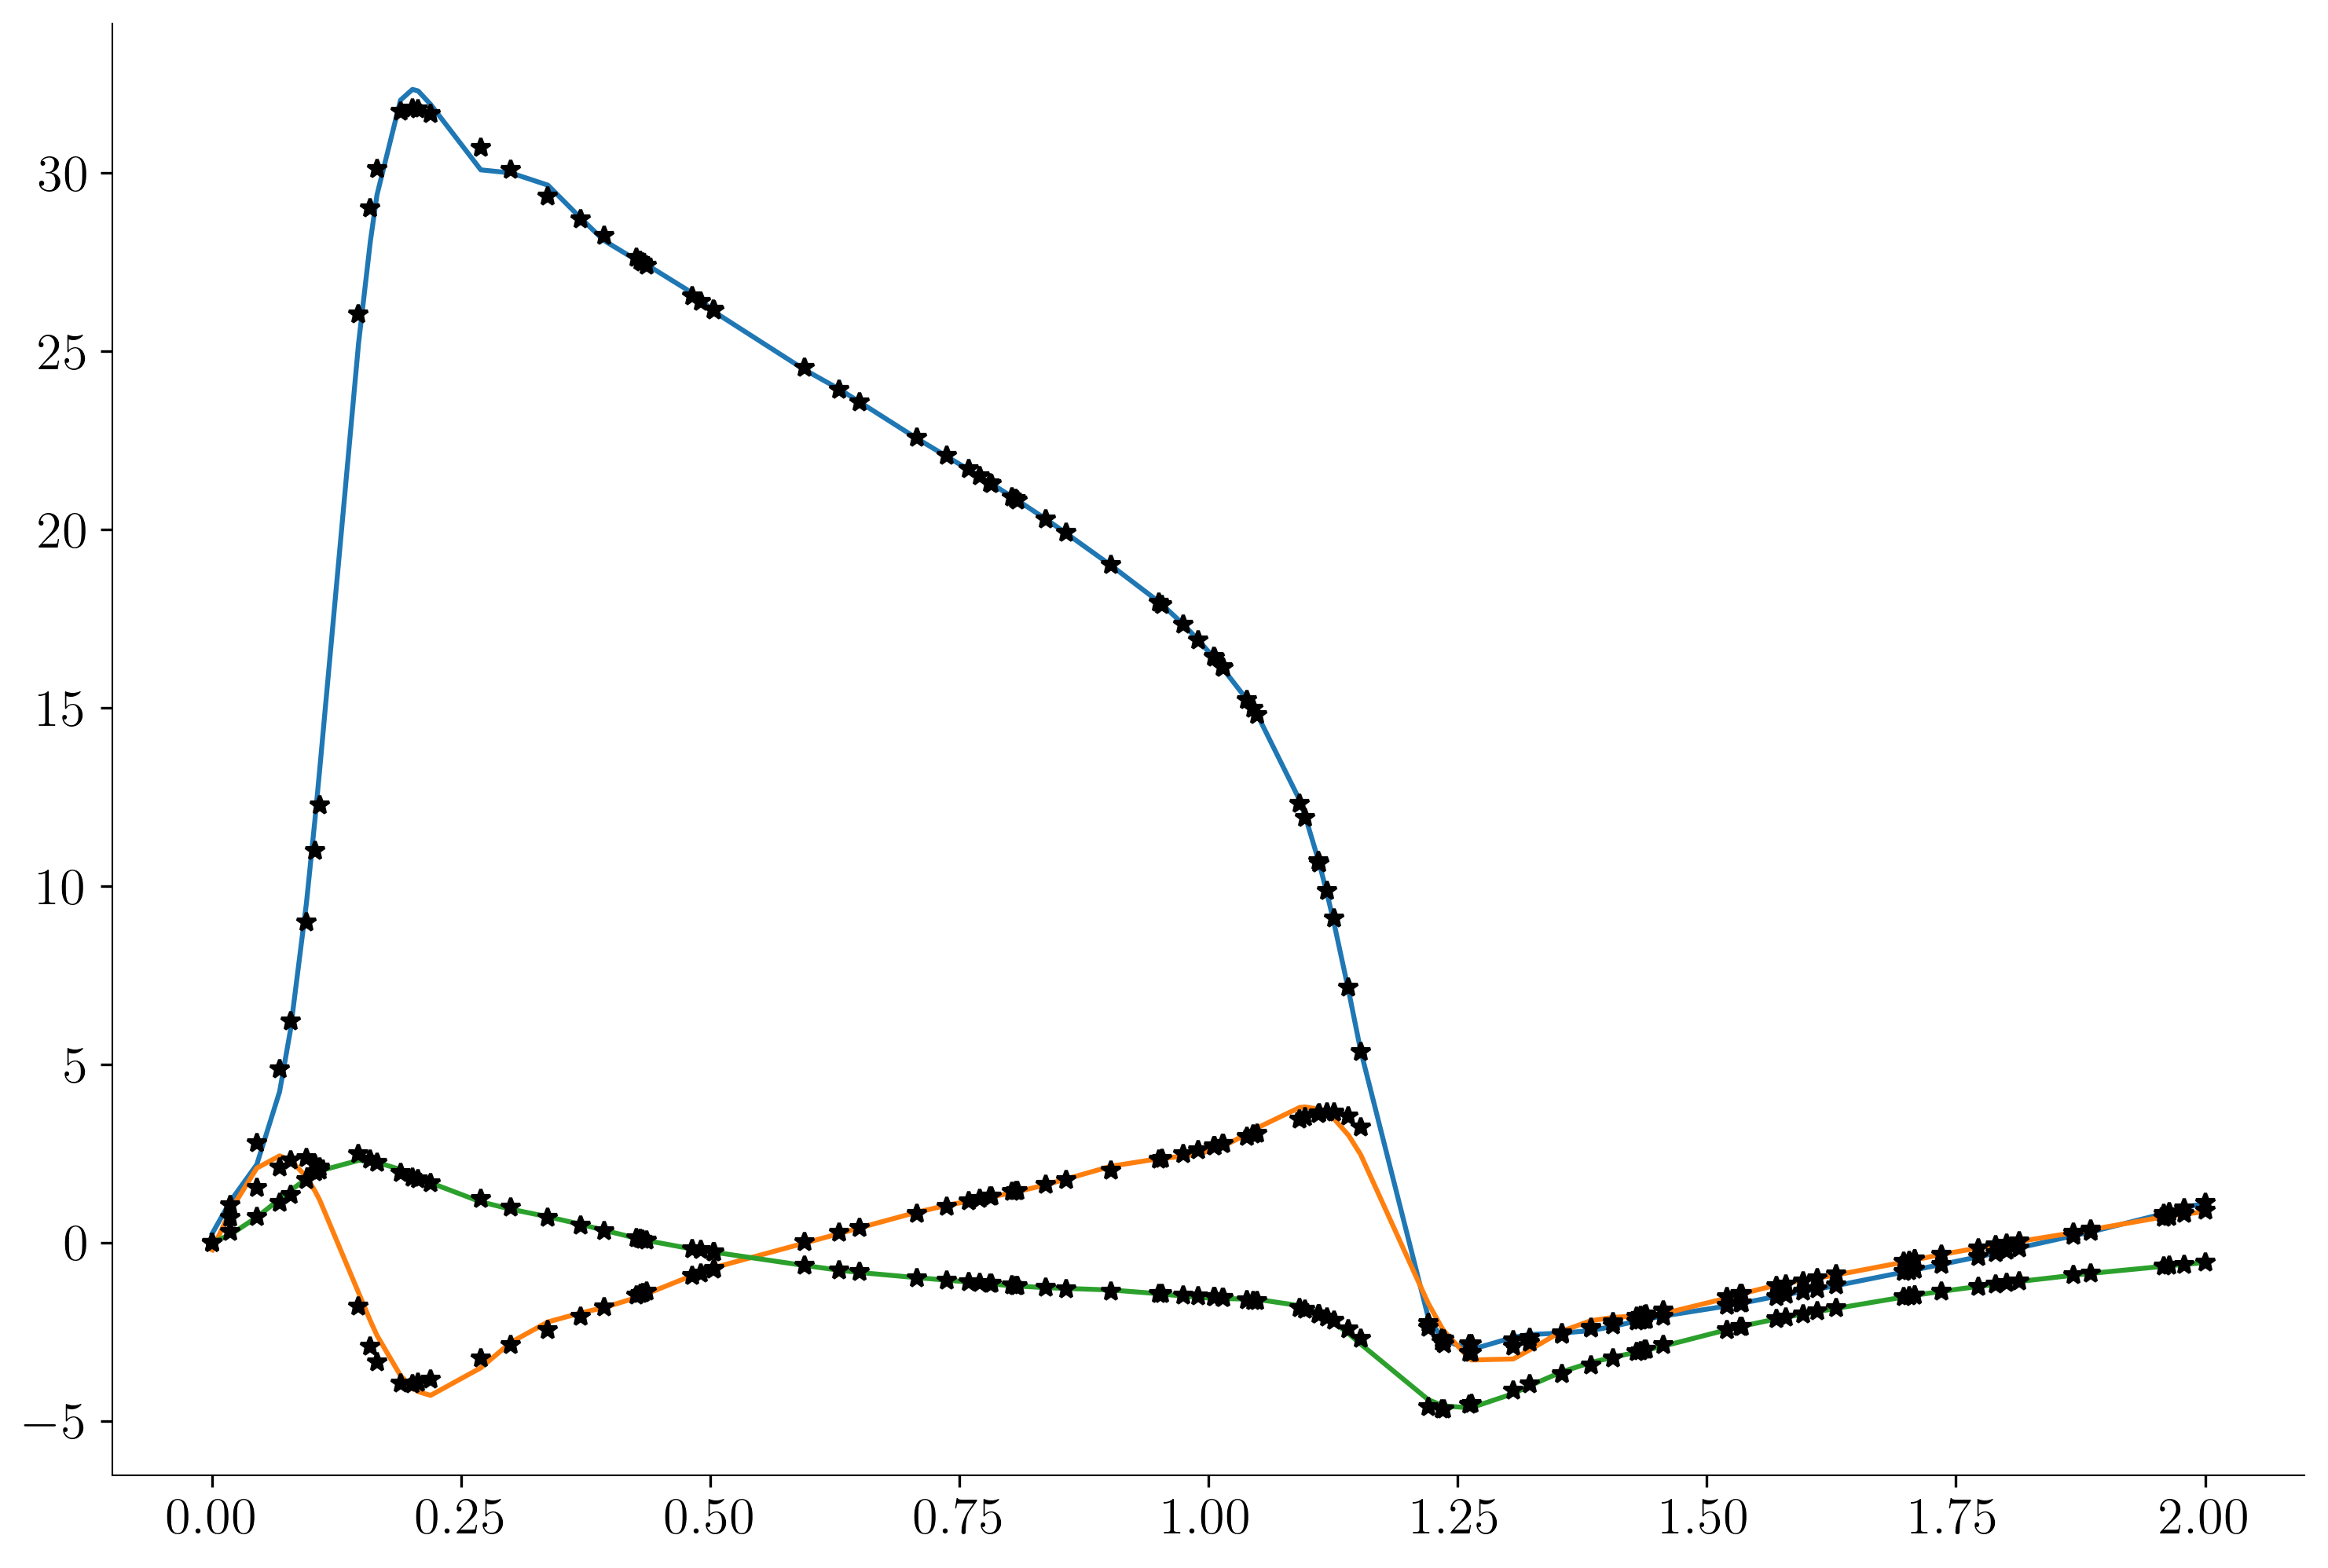

In [93]:
# Instatiate the rom
rom = config.ReducedOrderModel()
rom.state_dimension = len(gps)

input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) # TODO - Figure out what this really is?
states = np.array([gp.predict(X_train=time_domain_sampled[:,None], 
                      y_train=snapshots_compressed[mode, :].reshape(time_domain_sampled.size),
                      X_test=time_domain_sampled)[0] for mode, gp in enumerate(gps)])

plt.plot(time_domain_sampled, states.T)
plt.plot(time_domain_sampled, snapshots_compressed.T, 'k*')

 ConstantOperator
   state_dimension: 3
   entries.shape:   (3,),
 LinearOperator
   state_dimension: 3
   entries.shape:   (3, 3),
 QuadraticOperator
   state_dimension: 3
   entries.shape:   (3, 6),
 InputOperator
   state_dimension: 3
   input_dimension: 1
   entries.shape:   (3, 1),
 StateInputOperator
   state_dimension: 3
   input_dimension: 1
   entries.shape:   (3, 3)]

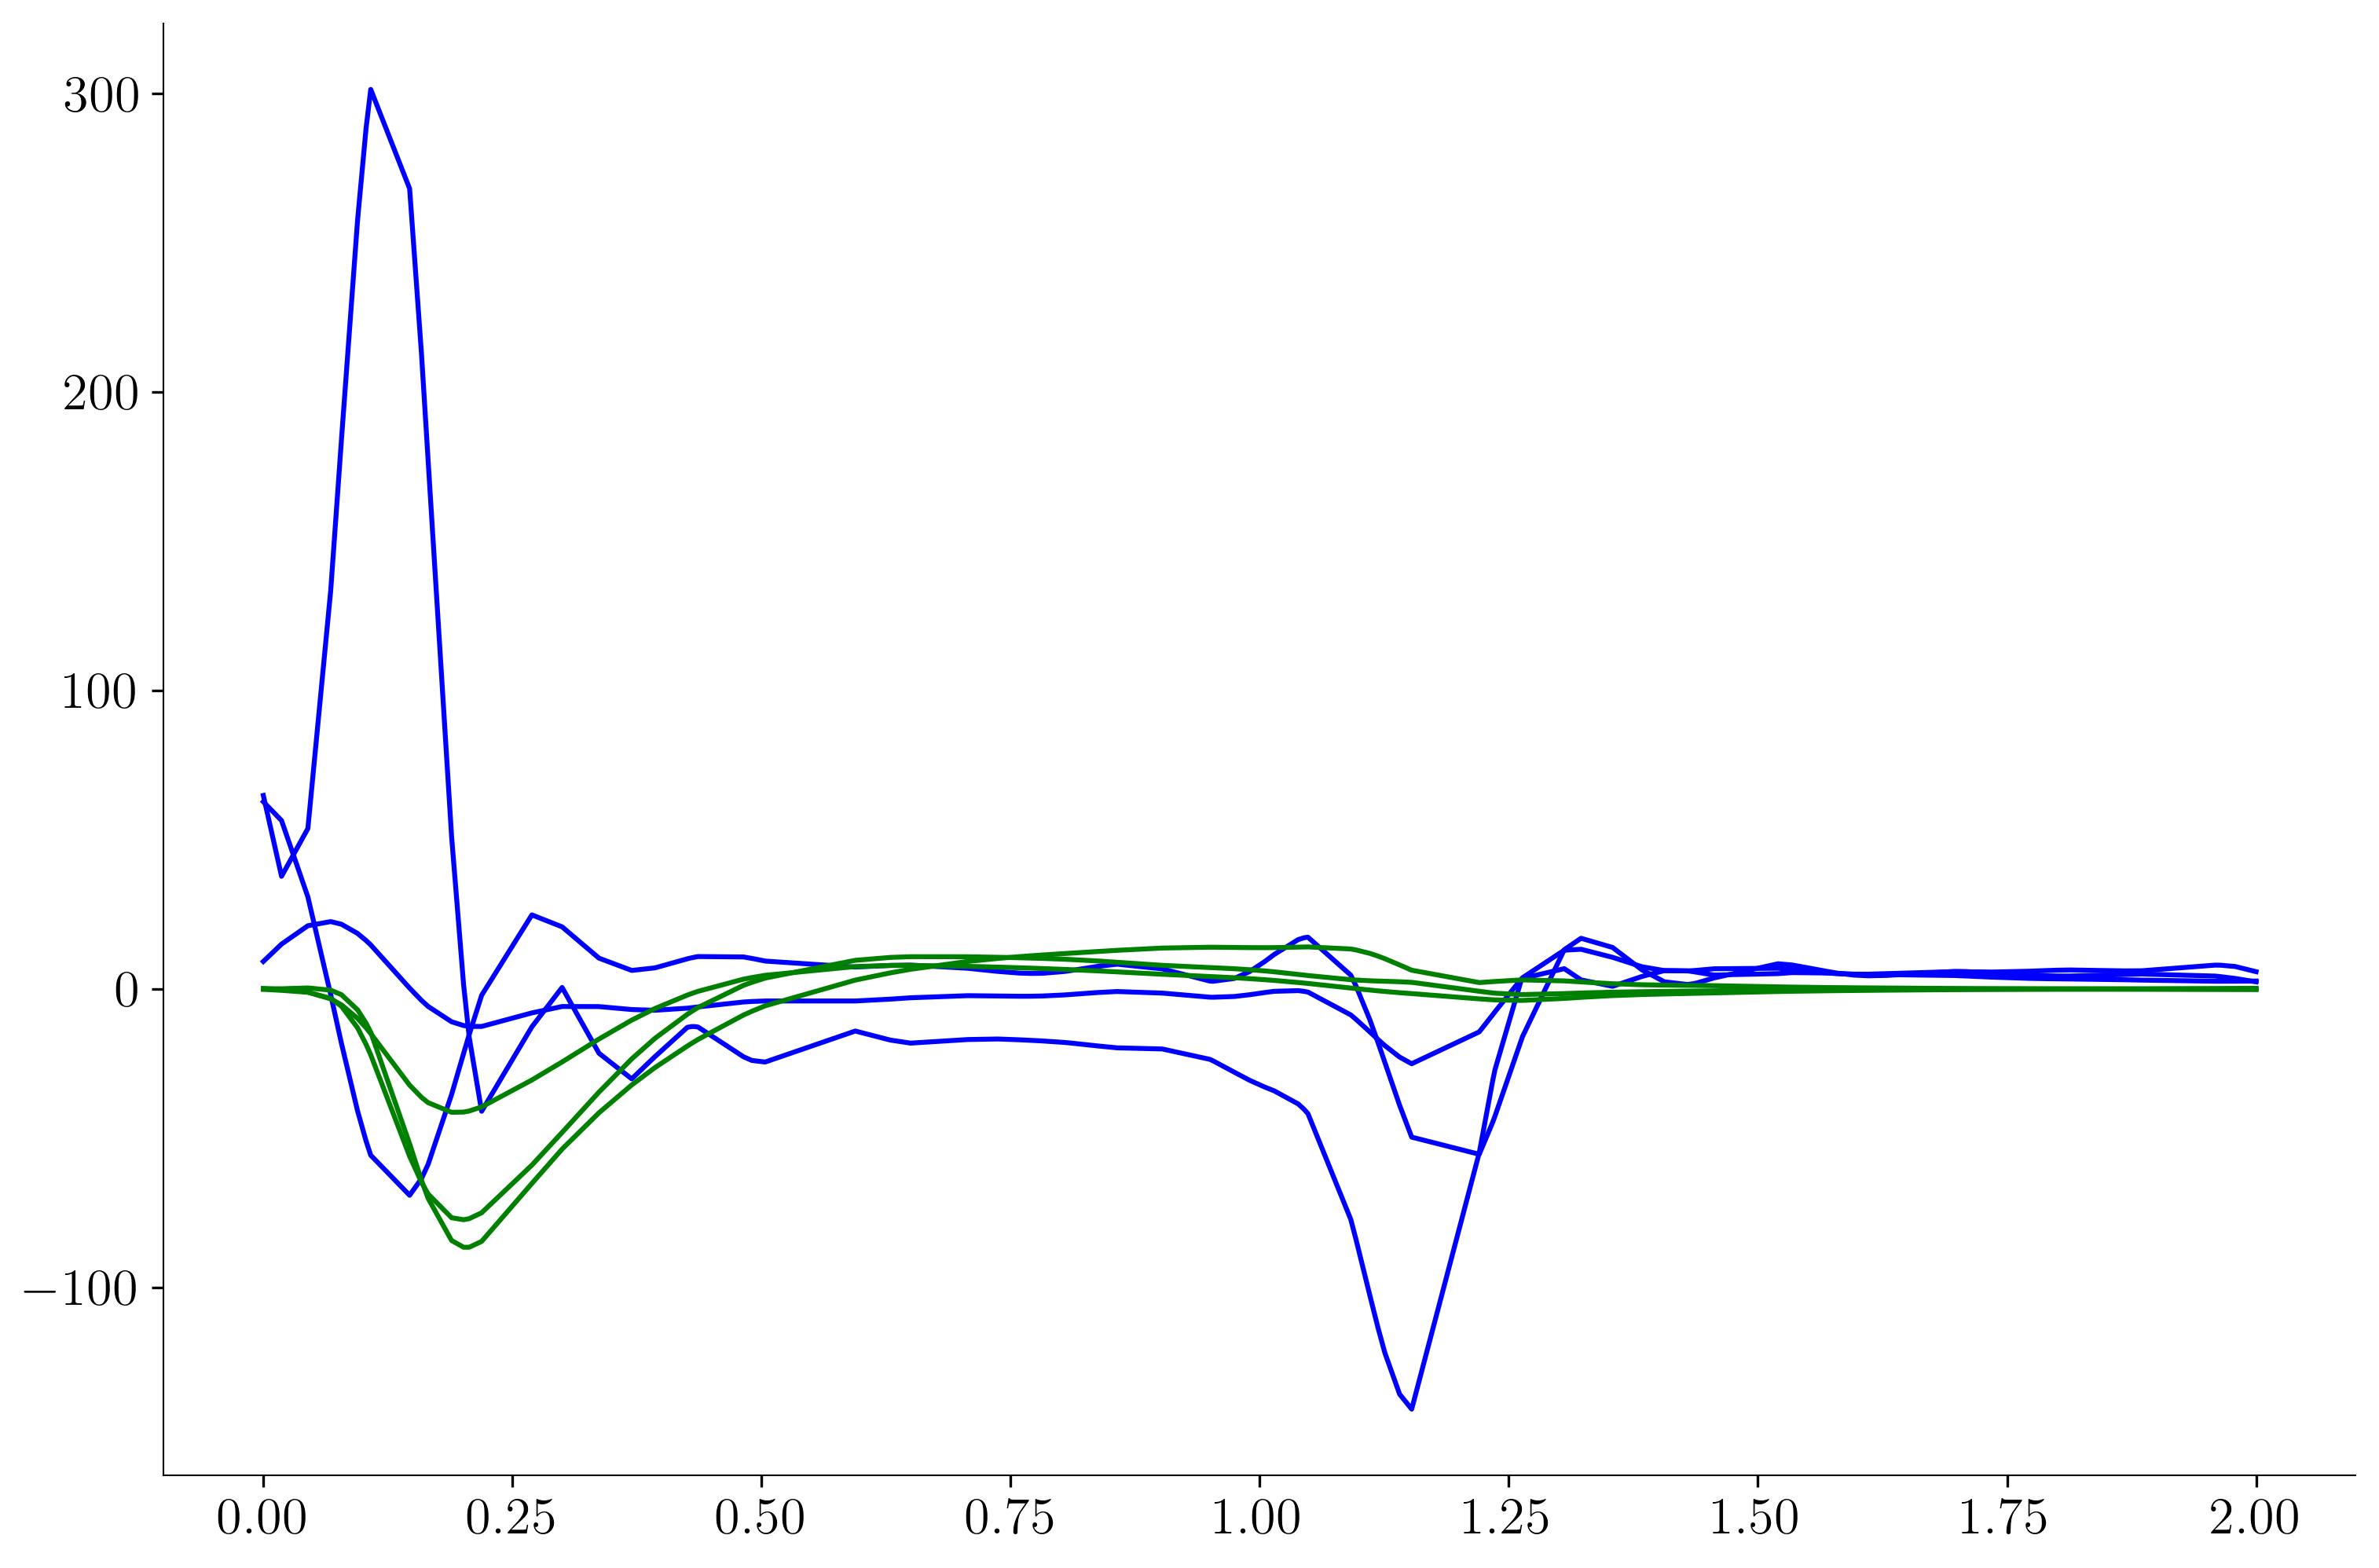

In [94]:
# Assemble data matrix and provide prior on O 
D = rom._assemble_data_matrix(states, inputs)
O = np.random.normal(loc=0, scale=.1, size = (3,14)) # TODO - Fix this hardcoding
deriv_pred =  O @ D.T

gp_derivatives = np.array([gp.predict_derivative(X_train=time_domain_sampled[:,None], 
                      y_train=snapshots_compressed[mode, :].reshape(time_domain_sampled.size),
                      X_test=time_domain_sampled)[0] for mode, gp in enumerate(gps)])

plt.plot(time_domain_sampled, gp_derivatives.T, color='b')
plt.plot(time_domain_sampled, deriv_pred.T, color='g')

rom._extract_operators(O)
rom.operators

In [ ]:
import numpyro
import numpyro.distributions as dist
from jax_gp import get_dash_c_phi
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from jax import jit

@jit
def batched_matmul(A, x):
    return jnp.einsum('bij,bj->bi', A, x) 

def model(rom, 
          compressed_snapshots, 
          K_yys, 
          noise_vars, 
          Dashs, 
          As, ):
    # Get the shape of our compressed snapshots
    n_modes, n_time = compressed_snapshots.shape
    
    # Prior on operator coefficients O
    operator_dims = rom.operator_matrix.shape
    
    
    # Sample gamma for each mode first (outside the main loop), this should be (n_modes,)
    with numpyro.plate('gamma_plate', n_modes):
        gamma_modes = numpyro.sample("gamma", dist.HalfCauchy(scale=1.0))
    
    # Sample O, this should be (d, n_modes)
    # p(\hat o_i)
    with numpyro.plate('r', operator_dims[1]):
        with numpyro.plate('d', operator_dims[0]):
            O = numpyro.sample(
                'O',
                dist.Normal(0, 30)
            )
    
    # For each reduced mode
    with numpyro.plate('reduced_modes', n_modes) as i:
        # Sample the latent GP function values, shape (n_modes, n_time)
        # p(X_i | \theta_i) = \mathcal{N}(0, K_{yy})
        X = numpyro.sample(
            "X", # y has shape [n_modes, n_time]
            dist.MultivariateNormal(loc=jnp.zeros(n_time), covariance_matrix=K_yys),
        )
        
        # Observation model: noisy observations of the compressed snapshots, shape (n_modes, n_time)
        # p(Y_i | X_i, \Chi) = \mathcal{N}(X_i, \Chi I)
        numpyro.sample(
            "Y",
            dist.Normal(X, noise_vars).to_event(1),
            obs=compressed_snapshots,
        )

        # Compute the \mu_{zi} as predicted from gaussian process, Dashs shape (n_modes,n_time, n_time) final shape (n)
        mu_z = batched_matmul(Dashs, X)
        D = rom._assemble_data_matrix(X, inputs)  # Assemble data mat
        predicted_derivative = O @ D.T
        
        # Compute the \Sigma_{zi} = A_i + \gamma_i I
        # As shape (n_modes, n_time, n_time), gamma (n_modes, )
        cov_z = As + gamma_modes[:, None, None] * jnp.repeat(jnp.eye(n_time, n_time)[None, :, :], 3, axis=0)
        
        # Gradient Matching part 
        numpyro.sample(f'grad_match',
                      dist.MultivariateNormal(mu_z, cov_z),
                      obs=predicted_derivative)

# Running the model
rng_key = jax.random.PRNGKey(0)
local_devices = jax.local_device_count()
numpyro.set_host_device_count(local_devices) 

nuts_kernel = NUTS(model, target_accept_prob=.65)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=500, num_chains=local_devices)

mcmc.run(rng_key, 
         rom=rom, 
         compressed_snapshots=jnp.array(snapshots_compressed), 
         K_yys=K_yys,
         noise_vars=noise_vars, 
         Dashs=Dashs, 
         As=As,)

### Extract Results and Plot

In [ ]:
# Get the samples from mcmc
samples = mcmc.get_samples()
print(f" Sample keys: {samples.keys()}")

mean_O = samples['O'].mean(axis=0)
mean_X = samples['X'].mean(axis=0)
mean_gamma = samples['gamma'].mean(axis=0)
print(mean_O.shape, mean_X.shape, mean_gamma.shape)

 Sample keys: dict_keys(['O', 'X', 'gamma'])
(3, 14) (3, 100) (3,)


### Plot the latent states predicted

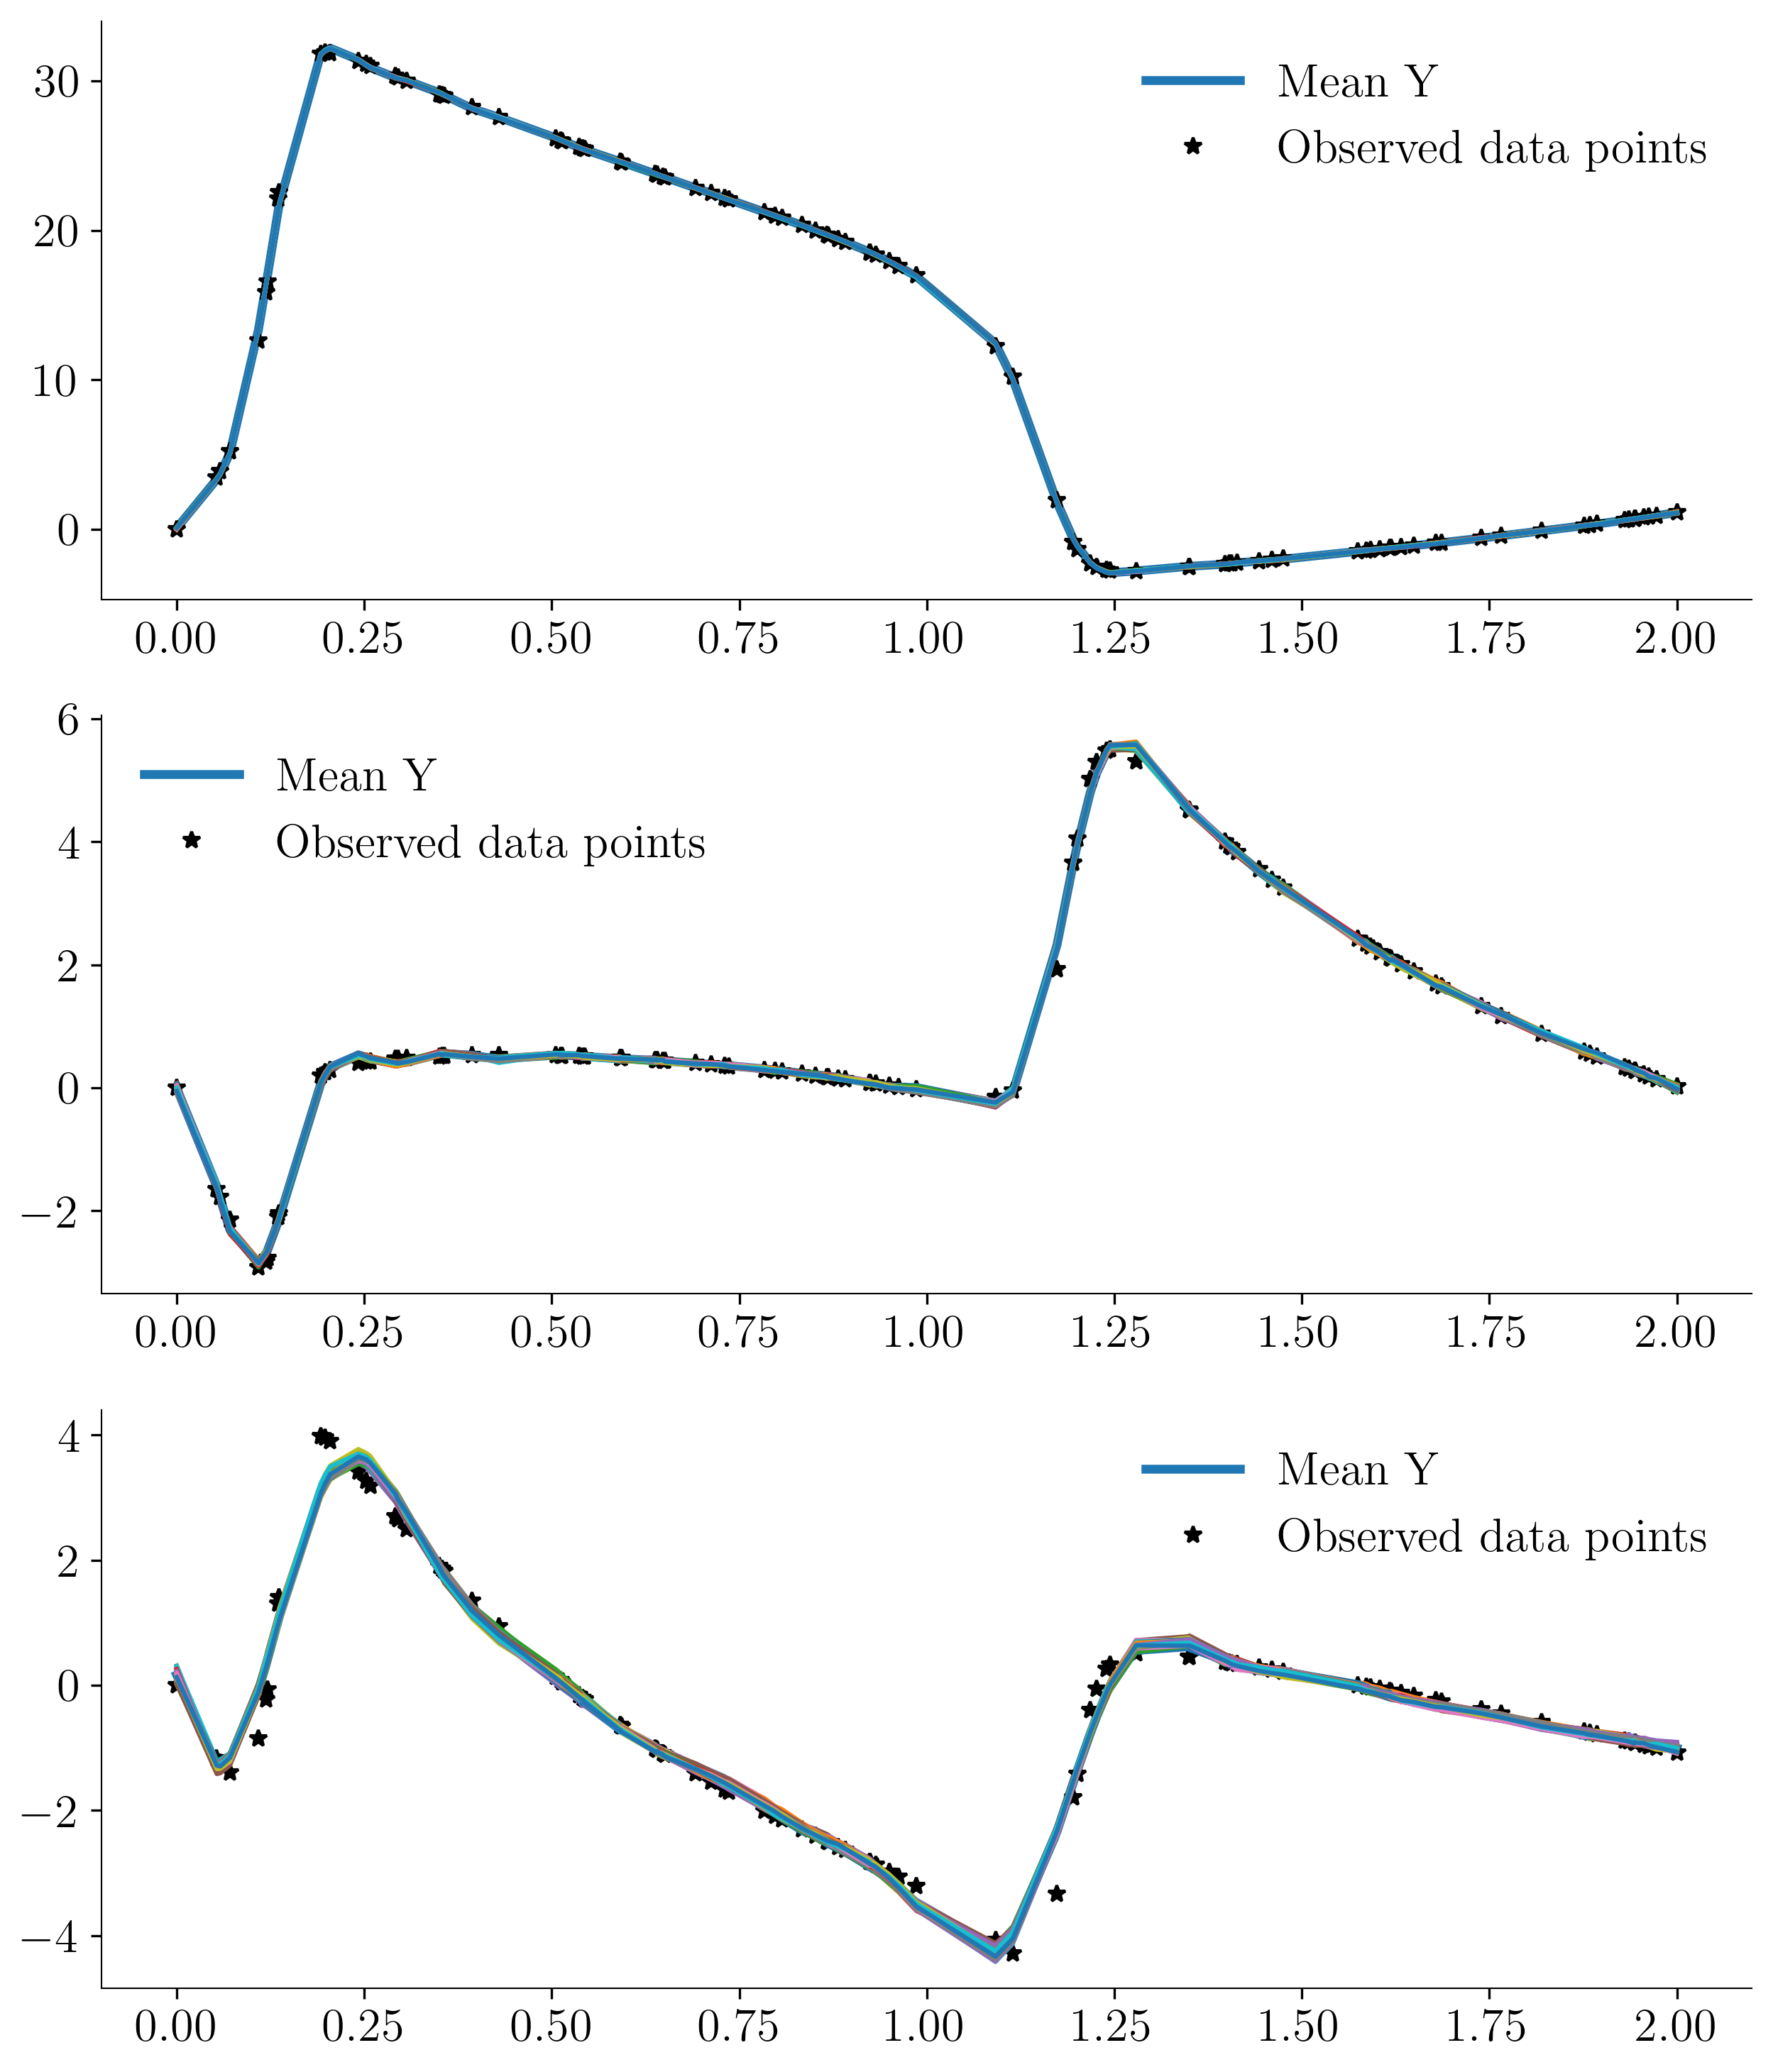

In [ ]:
mean_y = mean_X
X_samples = samples['X']
fig, ax = plt.subplots(numPODmodes, 1, figsize = (10,12))
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mean_y[i], lw=3, label='Mean Y')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label='Observed data points')

    
    sampled_indices = set()
    for j in range(min(ndraws, len(X_samples))):
        # Take many samples from posterior
        rand_idx = np.random.randint(0, len(samples['O']))
        while (rand_idx in sampled_indices):
            rand_idx = np.random.randint(0, len(samples['O']))
            
        sampled_indices.add(rand_idx)
        rand_y = X_samples[rand_idx]
        ax[i].plot(time_domain_sampled, rand_y[i])

    ax[i].legend()

### Plot O predictions

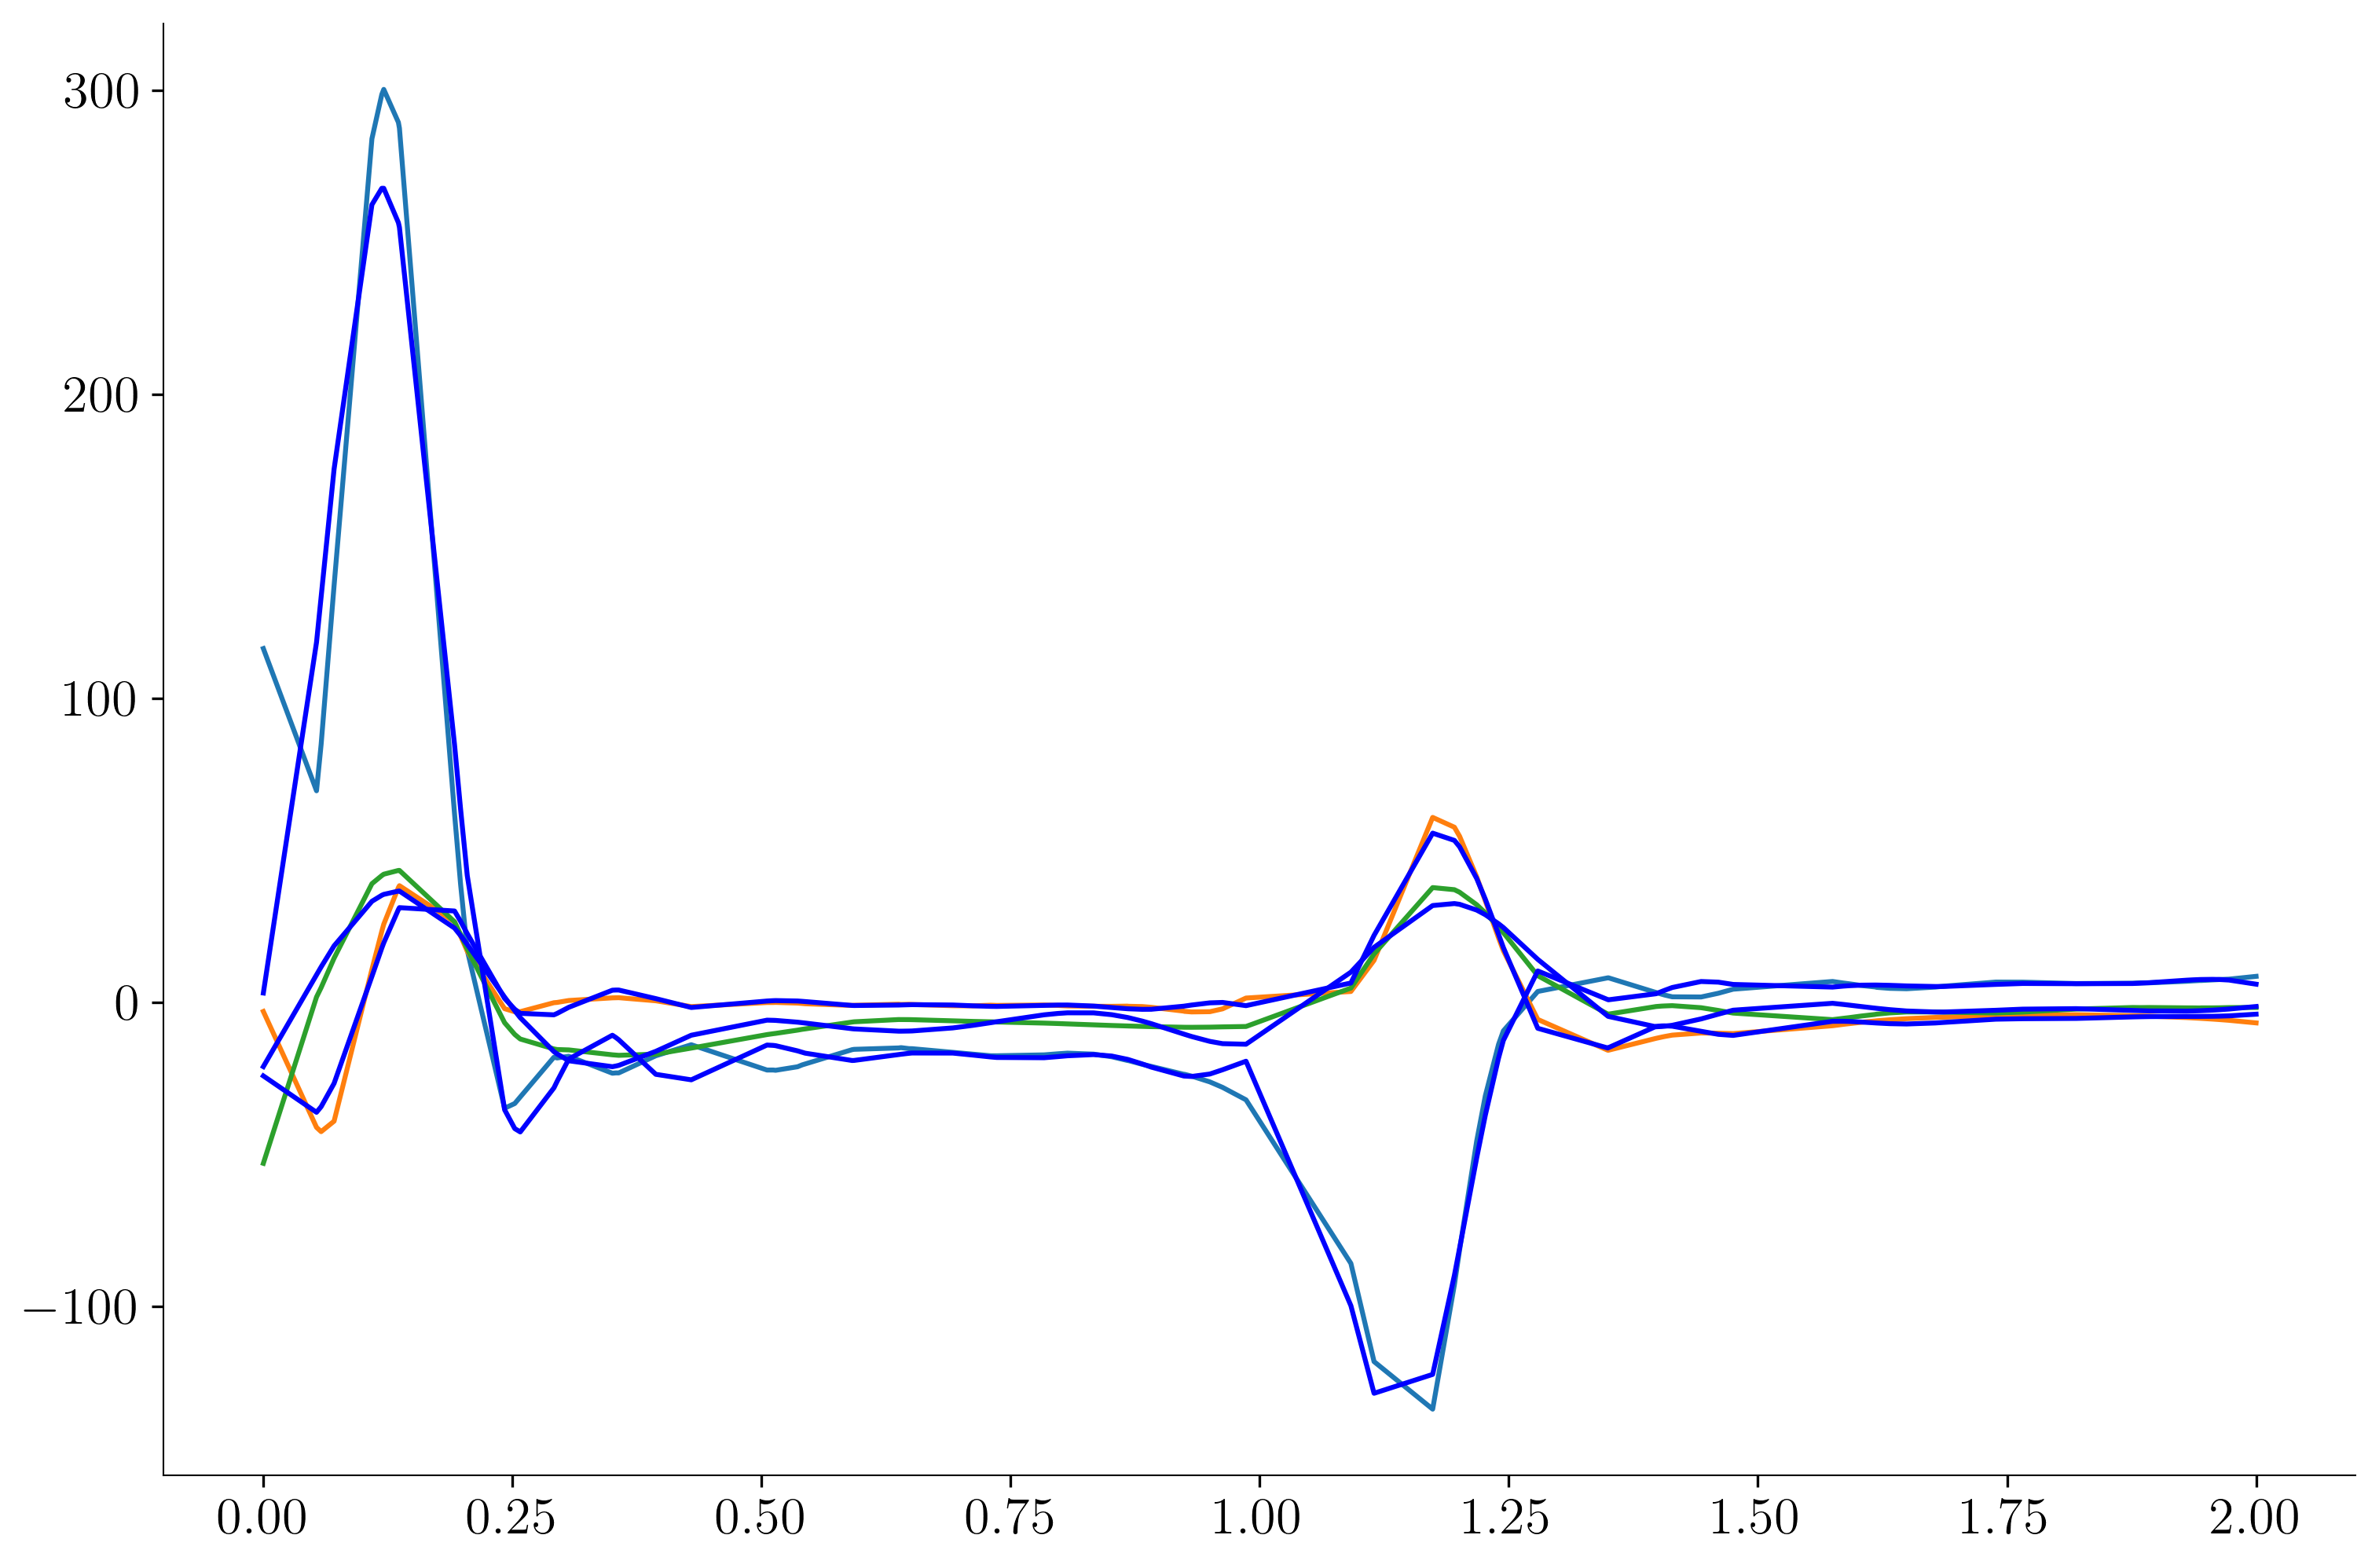

In [ ]:
mu_z = batched_matmul(Dashs, mean_X)
        
D = rom._assemble_data_matrix(mean_X, inputs)
predicted_derivative = mean_O @ D.T

plt.plot(time_domain_sampled, predicted_derivative.T)
plt.plot(time_domain_sampled, gp_derivatives.T, color='b')
# cov_z_i = As[i] + gamma * jnp.eye(n_time)
# # Likelihood for gradient matching
# numpyro.sample(f'grad_match',
#                 dist.MultivariateNormal(mu_z[i], cov_z_i),
#                 obs=predicted_derivative[i],)

### Plot predictions in the training domain

In [ ]:
# Get the mean operator
mean_O = samples['O'].mean(axis=0)
print(f" Mean operator : {samples['O'][0].shape}")

# Put the operator in the ROM
rom._extract_operators(np.array(mean_O))

# Plot predictions within training time domains
pred = rom.predict(state0=snapshots_compressed[:,0], t=time_domain_sampled, input_func=config.ReducedOrderModel.input_func)
sol = rom.predict_result_ 
print(sol.t.shape)          
print(sol.message) 

# Take many samples from posterior
sampled_indices = set()
trajectories = []
for i in range(min(ndraws, len(samples['O']))):
    rand_idx = np.random.randint(0, len(samples['O']))
    while (rand_idx in sampled_indices):
        rand_idx = np.random.randint(0, len(samples['O']))
    
    sampled_indices.add(rand_idx)
    rand_O = samples['O'][rand_idx]
    rom._extract_operators(np.array(mean_O))

    pred = rom.predict(state0=snapshots_compressed[:,0], t=time_domain_sampled, input_func=config.ReducedOrderModel.input_func)
    sol = rom.predict_result_ 
    
    if pred.size < snapshots_compressed.size:
        print("Failed, don't include")
    
    else:
        trajectories.append(pred)

# Compute some things for the drawn trajectories
trajectories = np.array(trajectories)
q1 = np.percentile(trajectories, 25, axis=0)
q3 = np.percentile(trajectories, 75, axis=0)
median_traj = np.median(trajectories, axis=0)

fig, ax = plt.subplots(3, 1, figsize=(10,12))
for i in range(numPODmodes):
    # Plot mean prediction vs observed
    ax[i].plot(sol.t, pred[i], label = 'Mean Operator Predicted States', lw=3)
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Observed Data Points')

    # Plot the many trajectories stuff
    ax[i].plot(time_domain_sampled, median_traj[i], label = 'Median Operator Predicted States')
    ax[i].fill_between(time_domain_sampled, q1[i], q3[i], alpha=.2)
    ax[i].legend()

 Mean operator : (3, 14)
(26,)
Required step size is less than spacing between numbers.
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include


/Users/anthonypoole/Repositories/rom-operator-inference-Python3/src/opinf/models/mono/_nonparametric.py:1057: IntegrationWarning: Required step size is less than spacing between numbers.
  warnings.warn(out.message, spintegrate.IntegrationWarning)


Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, don't include
Failed, do

IndexError: index -1 is out of bounds for axis 0 with size 0

#### Plot predictions in the full prediction domain

In [ ]:
# Plot predictions within training time domains
pred = rom.predict(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func)
sol = rom.predict_result_ 
print(sol.t.shape)          
print(sol.message) 

# Take many samples from posterior
sampled_indices = set()
trajectories = []
for i in range(min(ndraws, len(samples['O']))):
    rand_idx = np.random.randint(0, len(samples['O']))
    while (rand_idx in sampled_indices):
        rand_idx = np.random.randint(0, len(samples['O']))
    
    sampled_indices.add(rand_idx)
    rand_O = samples['O'][rand_idx]
    rom._extract_operators(np.array(mean_O))

    pred = rom.predict(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func)
    sol = rom.predict_result_ 
    
    if pred.size < full_states_compressed.size:
        print(f"Failed, don't include, stopped at step: {sol.t.size}")
    
    else:
        trajectories.append(pred)

# Compute some things for the drawn trajectories
trajectories = np.array(trajectories)
q1 = np.percentile(trajectories, 25, axis=0)
q3 = np.percentile(trajectories, 75, axis=0)
median_traj = np.median(trajectories, axis=0)

fig, ax = plt.subplots(3, 1, figsize=(10,12))
for i in range(numPODmodes):
    # Plot mean prediction vs observed
    ax[i].plot(sol.t, pred[i], label = 'Mean Operator Predicted States', lw=3)
    ax[i].plot(time_domain, full_states_compressed[i], 'black', label = 'True Data Points')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Oberserved Data')

    # Plot the many trajectories stuff
    ax[i].plot(time_domain, median_traj[i], label = 'Median Operator Predicted States')
    ax[i].fill_between(time_domain, q1[i], q3[i], alpha=.2)
    ax[i].legend()

(54,)
Required step size is less than spacing between numbers.
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at step: 54
Failed, don't include, stopped at 

IndexError: index -1 is out of bounds for axis 0 with size 0

### Deprecated old stuff

In [ ]:
O = np.array([
    [ 0.06179739,  0.13364818, -0.33357919, -0.40905816, -0.00683086, -1.53887612,
     -1.27187430, -0.96528121, -0.02780231, -2.10433663, -0.41249516, -0.12752775,
      2.48530606,  0.35913193],
    [-1.26890082,  1.08904774, -1.28876973, -0.30054625, -0.04125199,  0.41941927,
      0.24596876, -0.30306255,  0.45349731,  2.42508417,  0.01912359,  0.09015461,
      0.76488380,  0.30101646],
    [ 0.16980310, -0.23223301,  0.24188166,  0.00858180,  0.01331569,  0.31457090,
     -0.13222515,  0.22399142, -0.20878376, -0.40185565,  0.09041354, -0.01182961,
     -0.70702754, -0.20534039]
])

O.shape

# Define a prior mean if you want
prior_100_00 = np.array([
    [ 5.87047234e+01, -4.18175032e+00, -1.84556067e+01,  5.20674308e+01,
      1.86996854e-01, -5.31412835e+00, -4.56449011e-01,  3.04548099e-01,
     -4.04442960e+00,  5.65403665e-01, -6.78707416e-02,  2.25704559e-03,
      3.18384655e-01,  1.50119922e-01],
    [-4.58811367e+01,  2.79998150e+00,  3.52588282e+00, -4.42909619e+01,
     -3.60993811e-03, -1.91415115e+00, -3.72893514e+00,  2.33713128e+00,
     -5.64453163e+00, -2.33961308e+00,  3.60509019e-01, -1.41975142e-02,
      3.16748028e-02, -8.01783001e-02],
    [-1.63889647e+01,  3.31999062e-01,  8.05139941e-01, -1.73087772e+01,
      1.72822634e-02, -1.18431748e+00, -1.70528851e+00,  8.96560053e-01,
     -3.40140938e+00, -1.18621954e+00, -1.58125585e+00,  2.80451397e-02,
      1.22748488e-01, -2.12416822e-01]
])

In [ ]:
mean_O

Array([[ 1.0389059e+02, -1.9723085e+01, -6.8415024e+01,  8.3125801e+01,
         6.0673475e-01, -2.8243534e-02,  6.6077394e+00, -4.4214525e+00,
        -1.3155183e+01,  4.2835555e+00,  2.3138494e+00, -2.9101220e-01,
         1.9223118e+00,  3.0713680e-01],
       [-4.4182053e+00,  1.7688552e+00, -3.4772513e+00,  6.8737235e+00,
        -1.1013967e-01,  2.3518317e+00,  2.7582831e+00,  2.9711051e-02,
        -8.6253967e+00,  2.7627330e+00,  1.7569206e+01, -7.8549188e-01,
         4.3958735e+00,  1.7673496e+00],
       [-4.3922741e+01, -3.6237001e+00,  1.5982310e+01, -5.2239388e+01,
         1.8137296e-01,  4.3201375e-01, -8.7245715e-01,  1.2883252e+00,
         6.6263337e+00, -4.9835138e+00,  1.2893745e-01,  6.2341560e-03,
         4.6639152e+00, -1.5384629e+00]], dtype=float32)

In [ ]:
# import numpyro
# import numpyro.distributions as dist
# from jax_gp import get_dash_c_phi
# import jax
# import jax.numpy as jnp
# from numpyro.infer import MCMC, NUTS
# from jax import jit

# @jit
# def batched_matmul(A,x):
#    return jnp.einsum('bij,bj->bi', A, x) 


# def model(rom, 
#           compressed_snapshots, 
#           K_yys, 
#           noise_vars, 
#           Dashs, 
#           As, 
#           gamma = 1e-3, 
#           prior_O = None,
#           sigma_O = .1,
#           post_sigma_O = False):

#     # Get the shape of our compressed snapshots
#     n_modes, n_time = compressed_snapshots.shape
    
#     # Prior on operator coefficients O
#     # The dimension depends on your ROM structure (e.g., linear, quadratic, etc.)
#     operator_dims = rom.operator_matrix.shape

#     low  = jnp.full((operator_dims[1],), -50.)
#     high = jnp.full((operator_dims[1],),  75.)
#     with numpyro.plate('operator_rows', n_modes):
#         O = numpyro.sample(
#             'O',
#             dist.Uniform(low, high).to_event(1)
#         )

#     cov_z = As + gamma*jnp.eye(n_time)[None, :].repeat(3, axis=0)
    
#     # For each reduced mode
#     with numpyro.plate('reduced_modes', n_modes):
#         # Sample the latent GP function values
#         y = numpyro.sample(
#             "y", # y has shape [n_modes, n_time]
#             dist.MultivariateNormal(loc=jnp.zeros(n_time), covariance_matrix=K_yys)
#         )
        
#         # Observation model: noisy observations of the compressed snapshots
#         numpyro.sample(
#             "obs",
#             dist.Normal(y, noise_vars).to_event(1),
#             obs=compressed_snapshots
#         )

#         # center each state‐trajectory along the time axis
#         y_centered = y - y.mean(axis=1, keepdims=True)   # shape (D, T)

#         # apply Dash to each of the D centered vectors:
#         mu_z = batched_matmul(Dashs, y_centered)
        
#         D = rom._assemble_data_matrix(y, inputs)
#         predicted_derivative = O @ D.T

#         # Likelihood for gradient matching
#         numpyro.sample(f'grad_match',
#                       dist.MultivariateNormal(predicted_derivative, cov_z),
#                       obs=mu_z)

# # Some configs
# local_devices = jax.local_device_count()
# numpyro.set_host_device_count(local_devices) 

# # Running the model
# nuts_kernel = NUTS(model, target_accept_prob=0.90)
# mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000, num_chains=local_devices)
# rng_key = jax.random.PRNGKey(0)
# mcmc.run(rng_key, rom = rom, compressed_snapshots = snapshots_compressed, 
#         K_yys = K_yys,
#         gamma = 1e-2,
#         noise_vars = noise_vars, 
#         Dashs = Dashs, 
#         As = As,
#         post_sigma_O=True)